# Can a chart pattern really predict a price *and* a date? 🌀
### Wolfe Waves — a five-point wedge that promises a "natural equilibrium" target, tested by letting a computer draw it instead of a chartist

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![No_reliable_timer%3F: Confirmed](https://img.shields.io/badge/No_reliable_timer%3F-Confirmed-8b949e?style=flat-square)

Somewhere on a trading forum, someone has drawn five connected lines on a chart, labeled the points 1 through 5, and told you that price is now *destined* to travel to a specific level — the **EPA** ("Estimated Price at Arrival") — by a specific date. It's one of the more ambitious claims in chart reading: not just a direction, but a **price and a time**.

The trouble with testing folklore like this is that it's normally drawn by hand, after the fact, on whichever five points make the story work. So we built a computer that draws it the same way every time, on every chart, whether or not anyone wants it to — and asked whether the target it draws means anything at all.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the correlation math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** A 4% ZigZag finds the swing points on SPY plus a 7-ticker broad-index basket, 1993→2026 — no cherry-picked chart, no hindsight. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wolfe_waves import data, strategy as st

TICKERS = list(data.TICKERS)
HAVE_REAL = all(data.have_real(tk) for tk in TICKERS)
if HAVE_REAL:
    BASKET = data.load_basket(TICKERS)
else:
    BASKET = {}
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'pct': 0.04, 'asof': '2026-06-30', 'tickers': ('SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD'), 'per_ticker': {'SPY': (337, 44), 'QQQ': (431, 56), 'DIA': (275, 28), 'IWM': (381, 31), '^GSPC': (975, 114), '^IXIC': (612, 73), '^DJI': (315, 33), 'GLD': (217, 18)}, 'n_pivots': 3543, 'n_candidates': 370, 'n_decided': 345, 'n_timeout': 25, 'n_win': 120, 'n_loss': 225, 'hit_rate': 34.8, 'wilson': (29.9, 40.0), 'placebo_mean': 34.6, 'placebo_sd': 2.5, 'placebo_z': 0.05, 'placebo_p': 0.471, 'placebo_ndraws': 1000, 'tt_n': 120, 'tt_actual': 21.7, 'tt_pred': 52.2, 'tt_corr': 0.041, 'tt_mae': 40.8, 'fh': {5: (397, -40, -42, 47, -1.74, -2.0, 0.96), 10: (397, -14, -16, 50, -0.46, -0.48, 0.673), 20: (397, -1, -3, 47, -0.01, -0.01, 0.501), 40: (397, 20, 18, 47, 0.35, 0.37, 0.359)}, 'sweep': {0.03: (527, 500, 36.0), 0.04: (370, 345, 34.8), 0.05: (277, 247, 36.4), 0.08: (118, 90, 37.8)}, 'spy_candidates': 44, 'spy_decided': 40, 'spy_hit': 32.5, 'spy_wilson': (20.1, 48.0), 'syn_null_mean_t': -0.76, 'syn_null_sd': 1.25, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_planted_edge': 0.3, 'syn_planted': {5: (43, 317, 4.63, 5.62), 10: (43, 561, 4.11, 5.51), 20: (43, 668, 3.95, 5.32), 40: (43, 618, 3.17, 4.59)}, 'fp': {'SPY': '16694cd9912d', 'QQQ': 'd935154d0960', 'DIA': '33e3d47bdd3a', 'IWM': '1f2218a6b7f2', '^GSPC': 'cec06bce14e7', '^IXIC': '54d65c6aa4cb', '^DJI': '803513feb661', 'GLD': '44f6ff1685e4'}}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| Does the target actually get hit more than chance? | **No.** The pattern's price target gets hit **34.8%** of the time — a same-distance target dropped on a **random day** gets hit **34.6%** of the time. Statistically the same number. |
| Does the pattern at least call *when*? | **No — not even close.** Its own time projection correlates **+0.04** with when a winning trade actually resolves. A coin flip would do about as well. |
| Is this sensitive to how tightly you draw the wedge? | **No.** Loosen or tighten the swing filter and the hit rate barely moves (36%–38%) — there's no setting where the edge shows up. |
| Would the test even notice a *real* pattern? | **Yes.** On a fake chart where we deliberately plant a real reversal after point 5, the same detector lights up unmistakably. It's not blind — there's just nothing there on real markets. |

> The wedge is real geometry. The destiny isn't.

## 1 · The claim

> *"Five swing points — 1, 2, 3, 4, 5 — form a converging wedge. Point 5 pushes just past the line connecting points 1 and 3 — a 'false breakout' that traps the last sellers (or buyers) — and then price snaps back, traveling to the EPA line: the extension of the 1-4 trendline. That line tells you both the price AND roughly the time you'll get there."*

It's a more specific promise than most chart patterns make. Head-and-shoulders says *"probably down"*. Wolfe Waves says *"here, by then."* That specificity is exactly what makes it testable — and exactly what makes it worth testing.

## 2 · So what?

If the EPA line genuinely worked, it would be one of the few pieces of technical analysis offering a **concrete, falsifiable price-and-time forecast** — not just "probably higher" but "here, roughly then." That's a much bigger claim than most chart patterns make, and it should be correspondingly easy to grade: did price get there, and did it get there on schedule?

## 3 · How would we even know?

- **Find the wedges mechanically.** A ZigZag swing filter finds every 5-point sequence matching the wedge geometry — point 3 extends past point 1, point 4 stays inside the channel, point 5 breaks the 1-3 line. No human hindsight involved.
- **Draw the target.** Extend the 1-4 line to the moment point 5 is confirmed — that's the price target. Project the same time span forward from point 5 — that's the time target.
- **The luck check.** Walk forward and see whether price touches the target before an invalidation stop — then do the exact same walk from a **random day**, at the same distance, and see how often *that* touches too.
- **The clock check.** For the trades that do hit the target, does the pattern's own time projection actually predict when?

## 4 · The teardown — let's actually look

**First, the headline.** Hit rate of the real target vs a same-distance random-day target, pooled across the basket.

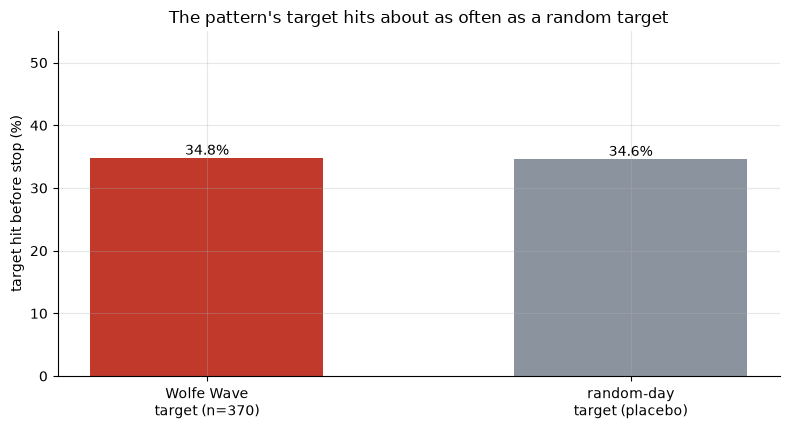

observed 34.8%  vs  placebo 34.6%


In [2]:
if HAVE_REAL:
    pooled = st.pooled_target_hit(BASKET, pct=R['pct'], max_horizon=90)
    hr = st.hit_rate_summary(pooled['ledger'])
    obs = hr['hit_rate'] * 100
else:
    obs = R['hit_rate']
placebo_mean = R['placebo_mean']  # canonical 1,000-draw/ticker placebo (results.md)
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.bar(['Wolfe Wave\ntarget (n=370)', 'random-day\ntarget (placebo)'],
       [obs, placebo_mean], color=[RED, GREY], width=.55)
for i, v in enumerate([obs, placebo_mean]):
    ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('target hit before stop (%)')
ax.set_title('The pattern\'s target hits about as often as a random target')
ax.set_ylim(0, 55)
plt.tight_layout(); plt.show()
print(f'observed {obs:.1f}%  vs  placebo {placebo_mean:.1f}%')

**34.8%** vs **34.6%** — a **z = 0.05**, a coin flip's worth of difference. Out of **370** algorithmically-detected wedges, **345** resolve one way or the other within 90 trading days (the rest simply never get close enough to either level); among those, **120** hit the target and **225** hit the invalidation stop first. That ratio is what a random walk gives you for free.

**Second — does it at least tell you *when*?**

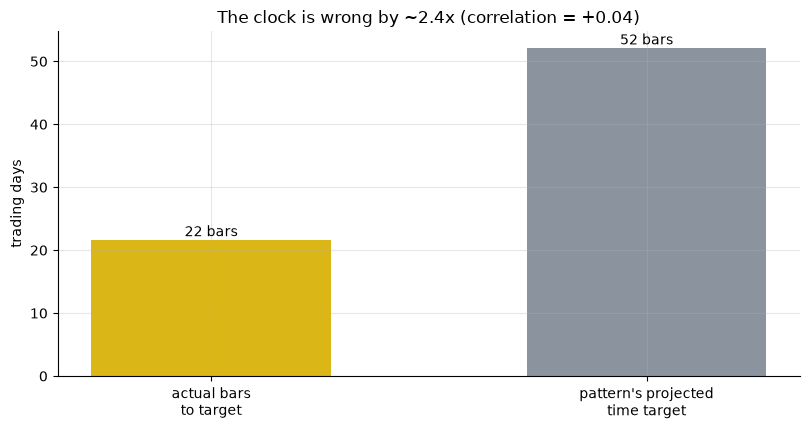

actual 21.7 days  vs  projected 52.2 days  corr=+0.041


In [3]:
if HAVE_REAL:
    tta = st.time_target_accuracy(pooled['ledger'])
    actual_mean, pred_mean, corr = tta['mean_actual'], tta['mean_predicted'], tta['corr']
else:
    actual_mean, pred_mean, corr = R['tt_actual'], R['tt_pred'], R['tt_corr']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['actual bars\nto target', "pattern's projected\ntime target"],
       [actual_mean, pred_mean], color=[AMBER, GREY], width=.55)
for i, v in enumerate([actual_mean, pred_mean]):
    ax.annotate(f'{v:.0f} bars', (i, v), ha='center', va='bottom')
ax.set_ylabel('trading days')
ax.set_title(f'The clock is wrong by ~2.4x (correlation = {corr:+.2f})')
plt.tight_layout(); plt.show()
print(f'actual {actual_mean:.1f} days  vs  projected {pred_mean:.1f} days  '
      f'corr={corr:+.3f}')

On the **120** trades that *do* reach the target, they get there in **22 trading days** on average — the pattern's own time projection says **52**. The two barely relate at all (correlation **+0.04**). Even when the price call happens to land, the date call is noise.

**Third, robustness.** Does loosening or tightening how strictly we draw the wedge change the answer?

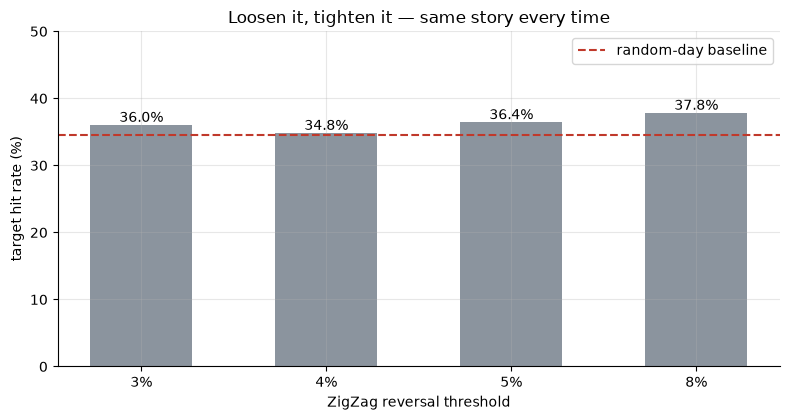

{'3%': '36.0%', '4%': '34.8%', '5%': '36.4%', '8%': '37.8%'}


In [4]:
pcts = sorted(R['sweep'])
hits = [R['sweep'][p][2] for p in pcts]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar([f'{p*100:.0f}%' for p in pcts], hits, color=GREY, width=.55)
ax.axhline(R['placebo_mean'], ls='--', c=RED, lw=1.5, label='random-day baseline')
for i, v in enumerate(hits):
    ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.set_xlabel('ZigZag reversal threshold')
ax.set_ylabel('target hit rate (%)')
ax.set_title('Loosen it, tighten it — same story every time')
ax.legend(); ax.set_ylim(0, 50)
plt.tight_layout(); plt.show()
print({f'{p*100:.0f}%': f'{h:.1f}%' for p, h in zip(pcts, hits)})

Flat, at every threshold from 3% to 8% — all sitting right on top of the random-day line. There's no secret setting where the pattern suddenly works.

**Finally — would this test even notice a real pattern if there were one?** We built a fake market where we deliberately plant a reversal after point 5, and reran the exact same detector.

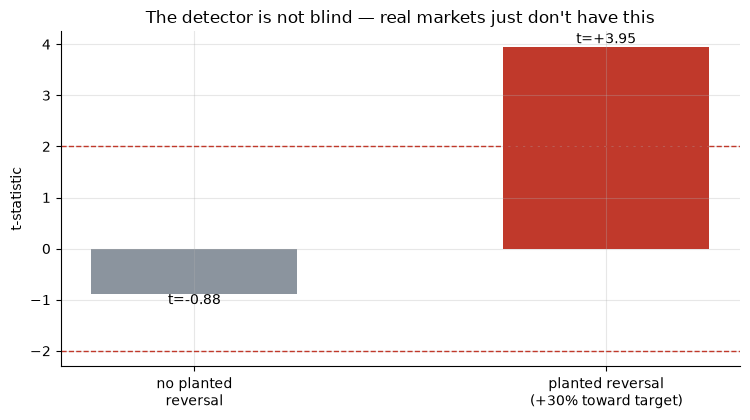

no reversal: t=-0.88   planted reversal: t=+3.95


In [5]:
def synth_run(edge, seed=697, horizon=20):
    bars, _ = data.synthetic_panel(edge=edge, seed=seed, n_days=9000)
    piv = st.zigzag(bars['close'].to_numpy(float), pct=R['pct'])
    ent = st.wolfe_candidates(piv)
    led = st.run_trades(bars, ent, horizon=horizon, cost_bps=0.0)
    return st.summarize(led, 'ret_gross')

s_null = synth_run(0.0)
s_plant = synth_run(R['syn_planted_edge'])
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['no planted\nreversal', 'planted reversal\n(+30% toward target)'],
       [s_null['t'], s_plant['t']], color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
for i, v in enumerate([s_null['t'], s_plant['t']]):
    ax.annotate(f't={v:+.2f}', (i, v), ha='center', va='bottom' if v>0 else 'top')
ax.set_ylabel('t-statistic')
ax.set_title('The detector is not blind — real markets just don\'t have this')
plt.tight_layout(); plt.show()
print(f"no reversal: t={s_null['t']:+.2f}   planted reversal: t={s_plant['t']:+.2f}")

With nothing planted, the detector reports nothing (comfortably inside the ±2 band). Force a real reversal into the fake data and the same detector lights up immediately. The machinery works — real markets simply don't hand it what it's looking for.

## 5 · The verdict

- **Signal — None.** The EPA target is hit **34.8%** of the time vs **34.6%** for a same-distance random target — statistically the same number, at every ZigZag setting we tried, on every fixed-horizon cut we ran. A synthetic control proves the harness would catch a real reversal if there were one.
- **Tradability — Mirage.** No edge, nothing to charge costs against, nothing to deploy.
- **"No reliable timer"? — Confirmed.** The time-and-price promise fails on the time half too: correlation **+0.04** between the projected and the actual arrival.

## 6 · Going further 🚪

- **This is a family, not a one-off.** Every chart pattern that claims a precise price target invites the same question: does the target beat a same-distance random day? [448-point-and-figure](../../448-point-and-figure/) asked exactly that of a different pattern — and found a real (if untradable) edge. Wolfe Waves didn't get that lucky.
- **The discretion problem is structural.** Wolfe's rules were never one canonical checklist — every source states them slightly differently. A human chartist, free to adjust which five points "count", has vastly more freedom to fit a story after the fact than the fixed rule this notebook ran.
- **Sibling studies:** [445-elliott-wave](../../445-elliott-wave/) (a different wave count, Fibonacci retracements, no price target), [447-gann-angles](../../447-gann-angles/) (a single trend line), and [704-three-drives](../../704-three-drives/) (another Fibonacci five-point pattern).

*Think a stricter or looser version of the wedge rules finds something real? The detector and its knobs are in [`wolfe_waves/strategy.py`](../wolfe_waves/strategy.py) — fork it and show a *t* ≥ 2 on the real tape.*